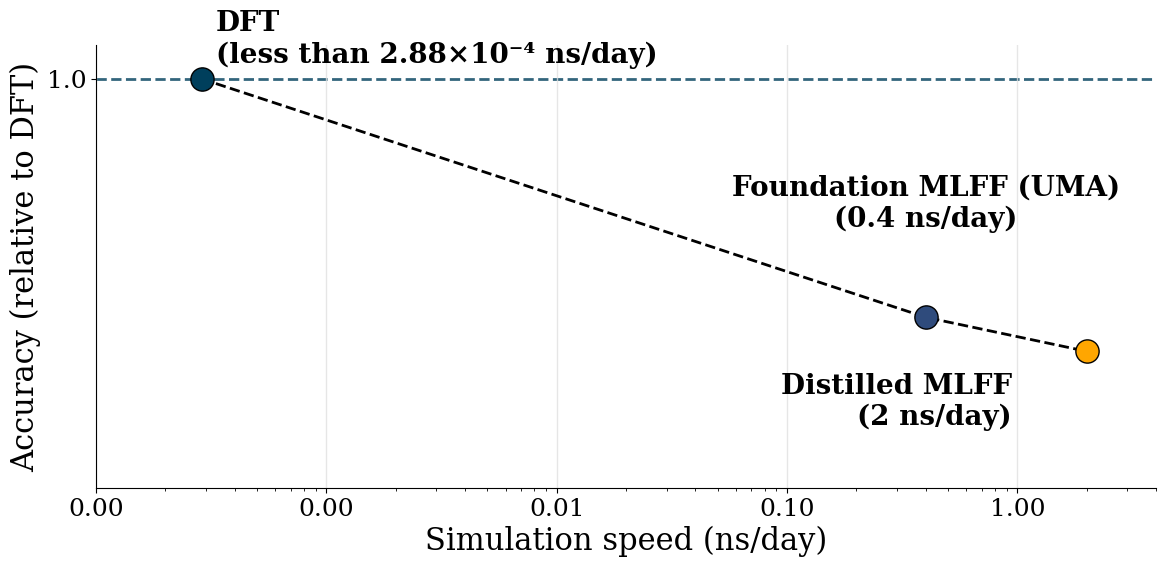

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# --- USER: Control all font sizes here ---
FONT_SIZES = {
    "font.family": "serif",
    "axes.labelsize": 22,    # Axis label (xlabel, ylabel)
    "font.size": 18,         # Default font size for text
    "axes.titlesize": 26,    # Title font size
    "xtick.labelsize": 18,   # X tick labels
    "ytick.labelsize": 18,   # Y tick labels
    "label_annotate_size": 20,  # Label annotate (for model points)
    "arrow_label_size": 18      # Arrow label font size
}
plt.rcParams.update({
    "font.family": FONT_SIZES["font.family"],
    "axes.labelsize": FONT_SIZES["axes.labelsize"],
    "font.size": FONT_SIZES["font.size"],
    "axes.titlesize": FONT_SIZES["axes.titlesize"],
    "xtick.labelsize": FONT_SIZES["xtick.labelsize"],
    "ytick.labelsize": FONT_SIZES["ytick.labelsize"],
})

# From main.ipynb (4-7), measured on GH200:
# DFT:        2.88×10⁻⁴ ns/day
# UMA:        0.4 ns/day
# Distilled:  2 ns/day

# Tabulate the model speed for x-axis (ns/day), and add to model info
model_data = [
    {
        "name": "DFT",
        "accuracy": 1.00,
        "ns_per_day": 2.88e-4,   # as float
        "gpu_hours": 1e5,
        "color": "#003f5c",
        "marker": "o",
        "display_speed": "less than 2.88×10⁻⁴"
    },
    {
        "name": "Foundation MLFF (UMA)",
        "accuracy": 0.93,
        "ns_per_day": 0.4,
        "gpu_hours": 1e2,
        "color": "#2f4b7c",
        "marker": "o",
        "display_speed": "0.4"
    },
    {
        "name": "Distilled MLFF",
        "accuracy": 0.92,  # Changed accuracy: higher than before, but no greater than UMA (0.93)
        "ns_per_day": 2,
        "gpu_hours": 1e1,
        "color": "#ffa600",
        "marker": "o",
        "display_speed": "2"
    }
]

# Sort by ns/day (ascending, for typical Pareto left-to-right progression)
model_data = sorted(model_data, key=lambda d: d["ns_per_day"])

# Extract plot values
speeds = [d["ns_per_day"] for d in model_data]
accuracies = [d["accuracy"] for d in model_data]
model_names = [d["name"] for d in model_data]
colors = [d["color"] for d in model_data]
markers = [d["marker"] for d in model_data]
display_speeds = [d["display_speed"] for d in model_data]

fig, ax = plt.subplots(figsize=(12, 6))

# Figure dimensions and axis bounds for margin checks
x_min, x_max = 1e-4, 4
y_min, y_max = 0.88, 1.01
x_range = np.log10(x_max) - np.log10(x_min)
y_range = y_max - y_min

# ---- WHERE TO CONTROL THE TEXT LOCATION ----
# Control the location of the text (labels) for each point by editing the `label_offsets` dictionary below.
# The keys must match the label substring, and the values are (offset, ha, va):
#   offset: tuple (x, y) in points for xytext offset,
#   ha: horizontal alignment ('left', 'center', 'right'),
#   va: vertical alignment ('top', 'bottom', 'center', etc.)
label_offsets = {
    "DFT":      {"offset": (10, 50),  "ha": "left",   "va": "top"},    # right and down
    "UMA":      {"offset": (0, 61),    "ha": "center", "va": "bottom"}, # above
    "Distilled":{"offset": (-54, -15), "ha": "right",  "va": "top"},    # left, slightly down
}
# For a new label, add a new entry or use the 'else' block below.

# Scatter points (larger markers for emphasis)
for x, y, label, color, marker, speed in zip(speeds, accuracies, model_names, colors, markers, display_speeds):
    ax.scatter(x, y, s=280, color=color, edgecolor='black', zorder=5, marker=marker)
    labeltext = f"{label}\n({speed} ns/day)"
    # Select labeling style according to label_offsets or fallback
    found = False
    for key in label_offsets:
        if key in label:
            off = label_offsets[key]
            offset = off["offset"]
            alignment = off["ha"]
            valign = off["va"]
            found = True
            break
    if not found:
        offset = (0, 15)
        alignment = 'center'
        valign = 'bottom'

    ax.annotate(
        labeltext, 
        xy=(x, y), 
        xytext=offset,
        textcoords='offset points',
        ha=alignment,
        va=valign,
        fontsize=FONT_SIZES.get("label_annotate_size", 16),  # Controlled font size for label
        fontweight='bold'
    )

# Draw Pareto frontier
ax.plot(speeds, accuracies, linestyle='--', color='black', linewidth=2, zorder=2)

# Dashed horizontal line for DFT (1.0 accuracy)
ax.axhline(y=1.0, color="#003f5c", linestyle="--", linewidth=2, alpha=0.8, zorder=1)

# Highlight the shift due to distillation with an arrow (if wanted, uncomment below)
arrowprops = dict(
    arrowstyle="->,head_width=1.6,head_length=1.6",
    linewidth=1.7,
    color='#666',
    shrinkA=10,
    shrinkB=10
)

# Determine UMA and Distilled locations (not used directly here, but preserved for reference)
uma_idx = next(i for i, d in enumerate(model_data) if "UMA" in d["name"])
distilled_idx = next(i for i, d in enumerate(model_data) if "Distilled" in d["name"])
# Draw arrow from UMA to Distilled (disabled)
# ax.annotate(
#     "Distillation\nshifts frontier",
#     xy=(speeds[uma_idx], accuracies[uma_idx]), 
#     xytext=(speeds[distilled_idx]*2, accuracies[distilled_idx]-0.01),  # Text away from arrow for clarity
#     textcoords="data",
#     va="bottom", ha="left",
#     fontsize=FONT_SIZES.get("arrow_label_size", 13),
#     arrowprops=arrowprops,
#     fontstyle='italic'
# )

# Set axes scales and labels
ax.set_xscale('log')
ax.set_xlabel("Simulation speed (ns/day)")
ax.set_ylabel("Accuracy (relative to DFT)")
ax.set_ylim(y_min, y_max)
ax.set_xlim(x_min, x_max)  # Covers 2.88e-4 for DFT up to 2 for Distilled

# X-tick formatting (show all in plain, with scientific if needed)
from matplotlib.ticker import LogLocator, ScalarFormatter, FixedLocator, FuncFormatter

# Custom log-scale ticks including all values
ax.xaxis.set_major_locator(LogLocator(base=10))
ax.xaxis.set_minor_locator(LogLocator(base=10, subs='auto'))
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.ticklabel_format(style='plain', axis='x')

# Only show 1.0 as y-tick, hide the rest
ax.yaxis.set_major_locator(FixedLocator([1.0]))
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: '1.0' if abs(y - 1.0) < 1e-8 else ''))

# Add light grid on x-axis only
ax.xaxis.grid(True, color="#e0e0e0", linestyle='-', linewidth=1, alpha=0.8)
ax.yaxis.grid(False)

# Remove top/right spines for clean look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()